# Agent Communication Matrix - Benchmarks Visualization

Visualize results from benchmarks.md with interactive charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Benchmark data from benchmarks.md
pattern1_data = {
    'Stage': ['Embedding (Ollama)', 'Oracle vector search', 'Total round-trip'],
    'Median (ms)': [14.1, 0.9, 15.3],
    'p95 (ms)': [15.2, 0.9, 16.3],
    'Min (ms)': [13.0, 0.8, np.nan],
    'Max (ms)': [15.6, 1.0, np.nan]
}

pattern2_data = {
    'Finding Size': ['500 chars', '1,000 chars', '2,000 chars', '3,000 chars'],
    'Naive Tokens': [341, 498, 919, 1355],
    'By-Ref Tokens': [61, 61, 61, 61],
    'Reduction': [5.6, 8.2, 15.1, 22.2]
}

df1 = pd.DataFrame(pattern1_data)
df2 = pd.DataFrame(pattern2_data)

print("Pattern 1: MCP Tool-Call Latency")
display(df1)
print("\nPattern 2: Token Reduction")
display(df2)

Pattern 1: MCP Tool-Call Latency


,Stage,Median (ms),p95 (ms),Min (ms),Max (ms)
0,Embedding (Ollama),14.1,15.2,13.0,15.6
1,Oracle vector search,0.9,0.9,0.8,1.0
2,Total round-trip,15.3,16.3,NaN,NaN



Pattern 2: Token Reduction


,Finding Size,Naive Tokens,By-Ref Tokens,Reduction
0,500 chars,341,61,5.6
1,"1,000 chars",498,61,8.2
2,"2,000 chars",919,61,15.1
3,"3,000 chars",1355,61,22.2


## Pattern 1: Latency Breakdown

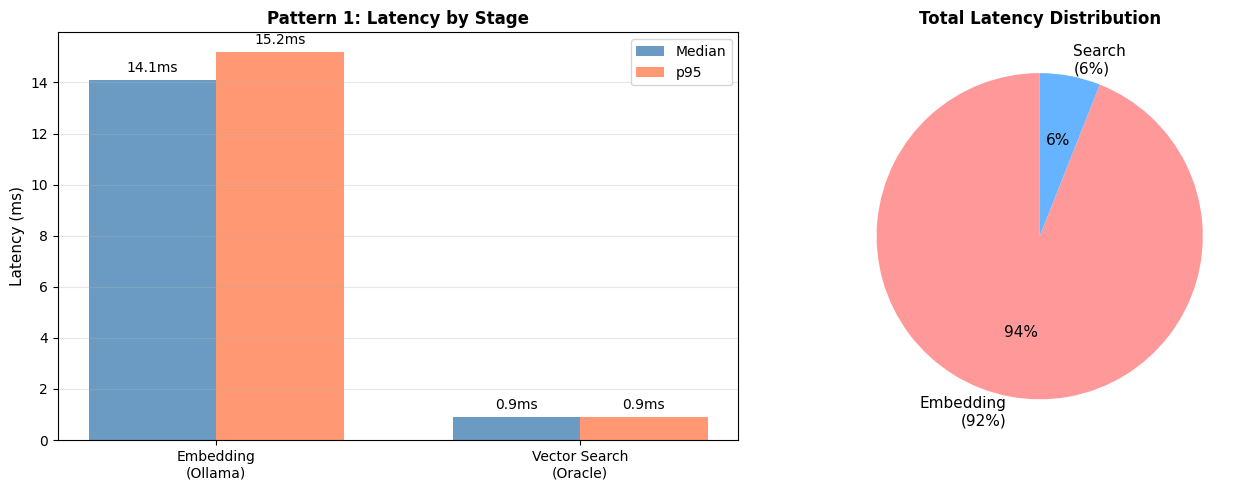


Key Insight: Embedding dominates at 14.1ms (92% of total latency)
Vector search is negligible at 0.9ms (6% of total latency)
Total round-trip: 15.3ms median, 16.3ms p95


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency by stage
stages = ['Embedding\n(Ollama)', 'Vector Search\n(Oracle)']
medians = [14.1, 0.9]
p95s = [15.2, 0.9]

x = np.arange(len(stages))
width = 0.35

axes[0].bar(x - width/2, medians, width, label='Median', alpha=0.8, color='steelblue')
axes[0].bar(x + width/2, p95s, width, label='p95', alpha=0.8, color='coral')
axes[0].set_ylabel('Latency (ms)', fontsize=11)
axes[0].set_title('Pattern 1: Latency by Stage', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stages)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (m, p) in enumerate(zip(medians, p95s)):
    axes[0].text(i - width/2, m + 0.3, f'{m:.1f}ms', ha='center', fontsize=10)
    axes[0].text(i + width/2, p + 0.3, f'{p:.1f}ms', ha='center', fontsize=10)

# Pie chart showing dominance
colors = ['#ff9999', '#66b3ff']
axes[1].pie([14.1, 0.9], labels=['Embedding\n(92%)', 'Search\n(6%)'], 
            autopct='%1.0f%%', startangle=90, colors=colors, textprops={'fontsize': 11})
axes[1].set_title('Total Latency Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKey Insight: Embedding dominates at 14.1ms (92% of total latency)")
print(f"Vector search is negligible at 0.9ms (6% of total latency)")
print(f"Total round-trip: 15.3ms median, 16.3ms p95")

## Pattern 2: Token Reduction Analysis

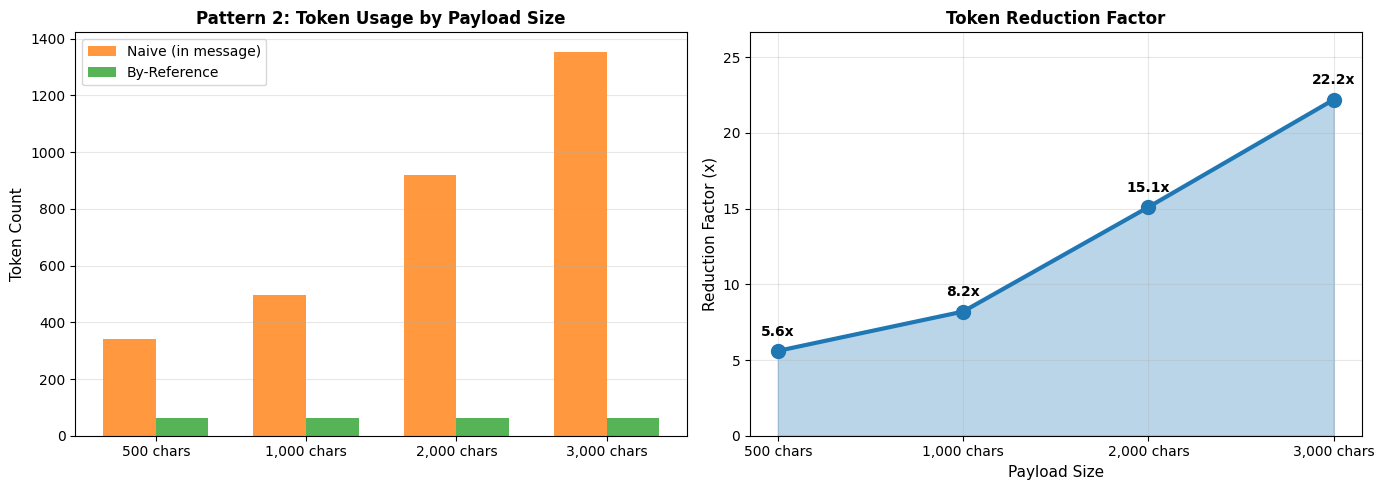


Key Insights:
  500 chars:  5.6x reduction (341 → 61 tokens)
  1KB chars:  8.2x reduction (498 → 61 tokens)
  2KB chars: 15.1x reduction (919 → 61 tokens)
  3KB chars: 22.2x reduction (1355 → 61 tokens) ← Maximum reduction


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token count comparison
sizes = df2['Finding Size'].tolist()
naive = df2['Naive Tokens'].tolist()
by_ref = df2['By-Ref Tokens'].tolist()

x = np.arange(len(sizes))
width = 0.35

axes[0].bar(x - width/2, naive, width, label='Naive (in message)', alpha=0.8, color='#ff7f0e')
axes[0].bar(x + width/2, by_ref, width, label='By-Reference', alpha=0.8, color='#2ca02c')
axes[0].set_ylabel('Token Count', fontsize=11)
axes[0].set_title('Pattern 2: Token Usage by Payload Size', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sizes)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Reduction factor curve
reductions = df2['Reduction'].tolist()
axes[1].plot(sizes, reductions, marker='o', linewidth=3, markersize=10, color='#1f77b4')
axes[1].fill_between(range(len(sizes)), reductions, alpha=0.3, color='#1f77b4')
axes[1].set_ylabel('Reduction Factor (x)', fontsize=11)
axes[1].set_xlabel('Payload Size', fontsize=11)
axes[1].set_title('Token Reduction Factor', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, max(reductions) * 1.2)

# Add value labels
for i, r in enumerate(reductions):
    axes[1].text(i, r + 1, f'{r:.1f}x', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"  500 chars:  5.6x reduction (341 → 61 tokens)")
print(f"  1KB chars:  8.2x reduction (498 → 61 tokens)")
print(f"  2KB chars: 15.1x reduction (919 → 61 tokens)")
print(f"  3KB chars: 22.2x reduction (1355 → 61 tokens) ← Maximum reduction")

## Combined Analysis: Latency vs Tokens

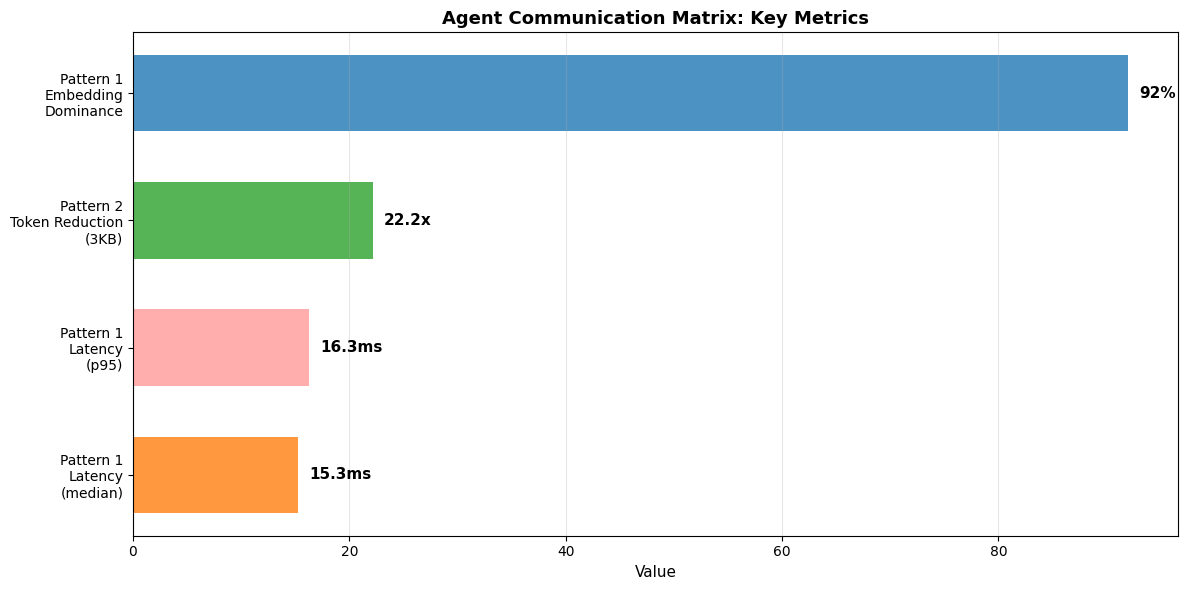

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create a comparison matrix
metrics = [
    'Pattern 1\nLatency\n(median)',
    'Pattern 1\nLatency\n(p95)',
    'Pattern 2\nToken Reduction\n(3KB)',
    'Pattern 1\nEmbedding\nDominance'
]

values = [15.3, 16.3, 22.2, 92]  # ms, ms, x reduction, %
colors_bar = ['#ff7f0e', '#ff9999', '#2ca02c', '#1f77b4']

bars = ax.barh(metrics, values, color=colors_bar, alpha=0.8, height=0.6)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    if i < 2:
        label = f"{val:.1f}ms"
    elif i == 2:
        label = f"{val:.1f}x"
    else:
        label = f"{val:.0f}%"
    ax.text(val + 1, i, label, va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Value', fontsize=11)
ax.set_title('Agent Communication Matrix: Key Metrics', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Recommendations

In [5]:
recommendations = """
    
RECOMMENDATIONS
===============

1. Pattern 1 (Tool-Call Latency)
   Use when: Real-time embedding is acceptable
   Latency: 15.3ms median
   Best for: Moderate-frequency queries
   Limitation: Embedding dominates (14.1ms)

2. Pattern 2 (Payload-by-Reference)
   Use when: Large findings (>1KB) need to be shared
   Reduction: 5.6x to 22.2x token savings
   Best for: Multi-agent conversations with heavy payloads
   Strategy: Store in Oracle, reference by ID

3. Combined Strategy
   - Use Pattern 1 for small queries (<500 chars)
   - Use Pattern 2 for research findings (>1KB)
   - Use Oracle vector search for semantic similarity
   - Result: Minimal latency + maximum token efficiency

Testing Environment
- Hardware: NVIDIA RTX 4090 (GPU-accelerated Ollama)
- Corpus: 1,000 synthetic chunks
- Index: HNSW (in-memory, cosine distance)
- Tokenizer: cl100k_base (GPT-4 family)
"""

print(recommendations)



RECOMMENDATIONS

1. Pattern 1 (Tool-Call Latency)
   Use when: Real-time embedding is acceptable
   Latency: 15.3ms median
   Best for: Moderate-frequency queries
   Limitation: Embedding dominates (14.1ms)

2. Pattern 2 (Payload-by-Reference)
   Use when: Large findings (>1KB) need to be shared
   Reduction: 5.6x to 22.2x token savings
   Best for: Multi-agent conversations with heavy payloads
   Strategy: Store in Oracle, reference by ID

3. Combined Strategy
   - Use Pattern 1 for small queries (<500 chars)
   - Use Pattern 2 for research findings (>1KB)
   - Use Oracle vector search for semantic similarity
   - Result: Minimal latency + maximum token efficiency

Testing Environment
- Hardware: NVIDIA RTX 4090 (GPU-accelerated Ollama)
- Corpus: 1,000 synthetic chunks
- Index: HNSW (in-memory, cosine distance)
- Tokenizer: cl100k_base (GPT-4 family)

